# 00. YOLO Sign Model Output Recheck

이 노트북의 목적은 **표지판 event 조건을 정하기 전에**, 현재 사용할 YOLO 모델이 어떤 형태의 출력을 내는지 다시 확인하는 것이다.

이번 노트북에서 하는 것:

- 기존 sign 모델 파일 위치 확인
- 모델 class 이름, 입력 크기, weight 파일 정보 확인
- 이전 학습 결과 CSV가 있으면 metric 요약 확인
- 샘플 이미지에 대해 detection을 수행하고, `class / confidence / bbox` 출력 구조 확인
- bbox의 위치와 크기를 event 설계에 쓸 수 있는 형태로 표로 저장
- overlay 이미지를 만들어 사람이 직접 detection 품질을 확인

이번 노트북에서 **아직 하지 않는 것**:

- ROI 확정
- event 발생 threshold 확정
- temporal voting/cooldown 확정
- state machine 연결

즉, 여기서는 "YOLO가 무엇을 내보내는가"만 다시 이해한다.

## 0. 실행 환경 준비

이 노트북은 `<env>` 커널에서 실행하는 것을 기준으로 한다.

필요한 패키지 중 `ultralytics`가 없으면 아래 코드셀이 현재 커널의 Python에 설치한다.
설치 후 import가 바로 되지 않으면 커널을 한 번 재시작하고 다시 Run All 하면 된다.


In [1]:
import sys, subprocess, importlib.util
print('python:', sys.executable)
print('version:', sys.version)

required = ['ultralytics']
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
print('missing:', missing)

if missing:
    # 현재 Jupyter 커널의 Python에 설치한다.
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
    print('installed:', missing)
else:
    print('ultralytics already installed')


python: ~\anaconda3\envs\<env>\python.exe
version: 3.10.18 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:08:55) [MSC v.1929 64 bit (AMD64)]
missing: ['ultralytics']
installed: ['ultralytics']


## 1. 경로와 실험 위치

19번 폴더는 prototype으로 보존했고, 20번 폴더는 sign event contract를 다시 잡기 위한 새 실험 폴더다.

이 노트북은 `20_sign_event_contract/notebooks` 아래에 있으며, 결과물은 `review_outputs/00_yolo_model_output_recheck` 아래에 저장한다.

In [2]:
from pathlib import Path
import json
import time
import math
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import cv2

try:
    from IPython.display import display, Image as IPyImage
except Exception:
    display = None
    IPyImage = None

NOTEBOOK_DIR = Path.cwd()
# 노트북을 notebooks 폴더에서 실행한다고 가정하되, 다른 위치에서 실행해도 20번 폴더를 찾는다.
if NOTEBOOK_DIR.name == "notebooks":
    EXP20_DIR = NOTEBOOK_DIR.parent
else:
    candidates = [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
    EXP20_DIR = next((p for p in candidates if p.name == "20_sign_event_contract"), NOTEBOOK_DIR)

EXP_ROOT = EXP20_DIR.parent
PROJECT_ROOT = EXP_ROOT.parent
EXP07_DIR = EXP_ROOT / "07_sign_detection_yolo"
EXP08_DIR = EXP_ROOT / "08_sign_runtime_event_validation"
EXP19_PROTO_DIR = EXP_ROOT / "19_final_drive_runtime_prototype"
SHARED_MODELS_DIR = PROJECT_ROOT / "20_shared_assets" / "models"
SIGN_SHARED_DIR = SHARED_MODELS_DIR / "sign_yolo11n_field2_v1"

OUT_DIR = EXP20_DIR / "review_outputs" / "00_yolo_model_output_recheck"
OVERLAY_DIR = OUT_DIR / "overlays"
TABLE_DIR = OUT_DIR / "tables"
for p in [OUT_DIR, OVERLAY_DIR, TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("EXP20_DIR:", EXP20_DIR)
print("EXP07_DIR exists:", EXP07_DIR.exists())
print("EXP08_DIR exists:", EXP08_DIR.exists())
print("EXP19_PROTO_DIR exists:", EXP19_PROTO_DIR.exists())
print("OUT_DIR:", OUT_DIR)

EXP20_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract
EXP07_DIR exists: True
EXP08_DIR exists: True
EXP19_PROTO_DIR exists: True
OUT_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\00_yolo_model_output_recheck


## 2. 사용할 모델 후보 확인

YOLO 모델은 여러 위치에 있을 수 있다.

우선순위는 다음과 같이 둔다.

1. 19번 prototype 패키지 안에 들어간 최종 후보 ONNX
2. 08번 runtime validation에서 쓰던 `sign.onnx`
3. 07번 학습 결과의 `light_aug_v2` best ONNX
4. 07번 학습 결과의 `clean_v1` best ONNX

여기서는 모델을 새로 고르지 않는다. 현재 패키지에서 사용하던 후보를 우선으로 불러오고, 나머지는 비교 참고용으로 목록만 남긴다.

In [3]:
model_candidates = [
    SIGN_SHARED_DIR / "sign_yolo11n_field2_light_aug_best.onnx",
    SIGN_SHARED_DIR / "sign_yolo11n_field2_clean_best.onnx",
    EXP19_PROTO_DIR / "team3_final_drive" / "models" / "sign" / "sign_yolo11n_field2_light_aug.onnx",
    EXP08_DIR / "models" / "sign.onnx",
    EXP07_DIR / "colab_outputs" / "yolo11n_field2_20260507" / "field2_light_aug_v2_yolo11n" / "weights" / "best.onnx",
    EXP07_DIR / "colab_outputs" / "yolo11n_field2_20260507" / "field2_clean_v1_yolo11n" / "weights" / "best.onnx",
]

rows = []
for p in model_candidates:
    rows.append({
        "exists": p.exists(),
        "path": str(p),
        "size_mb": round(p.stat().st_size / (1024 * 1024), 2) if p.exists() else None,
    })
model_df = pd.DataFrame(rows)
display(model_df)

MODEL_PATH = next((p for p in model_candidates if p.exists()), None)
assert MODEL_PATH is not None, "No sign model candidate found."
print("Selected MODEL_PATH:", MODEL_PATH)

,exists,path,size_mb
0,True,~\02_Projects\University\26-1_Em...,10.12
1,True,~\02_Projects\University\26-1_Em...,10.12
2,True,~\02_Projects\University\26-1_Em...,10.12
3,True,~\02_Projects\University\26-1_Em...,10.12
4,True,~\02_Projects\University\26-1_Em...,10.12
5,True,~\02_Projects\University\26-1_Em...,10.12


Selected MODEL_PATH: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\models\sign_yolo11n_field2_v1\sign_yolo11n_field2_light_aug_best.onnx


## 3. 패키지와 모델 메타데이터 확인

가능하면 `ultralytics.YOLO`로 모델을 로드한다. 이 방식은 ONNX 모델이라도 YOLO의 후처리까지 같이 수행해주므로, 우리가 실제 runtime에서 기대하는 `bbox/conf/class` 구조를 확인하기 쉽다.

만약 `ultralytics`가 설치되어 있지 않으면, 이 노트북은 모델 파일 존재와 ONNX input/output shape까지만 확인한다. 이 경우 아래 셀의 안내에 따라 환경을 맞춘 뒤 다시 실행하면 된다.

In [4]:
HAS_ULTRALYTICS = False
HAS_ONNXRUNTIME = False
try:
    from ultralytics import YOLO
    HAS_ULTRALYTICS = True
except Exception as e:
    YOLO = None
    print("ultralytics import failed:", repr(e))

try:
    import onnxruntime as ort
    HAS_ONNXRUNTIME = True
except Exception as e:
    ort = None
    print("onnxruntime import failed:", repr(e))

print("HAS_ULTRALYTICS:", HAS_ULTRALYTICS)
print("HAS_ONNXRUNTIME:", HAS_ONNXRUNTIME)

if HAS_ONNXRUNTIME:
    sess = ort.InferenceSession(str(MODEL_PATH), providers=["CPUExecutionProvider"])
    print("ONNX inputs:")
    for inp in sess.get_inputs():
        print(" ", inp.name, inp.shape, inp.type)
    print("ONNX outputs:")
    for out in sess.get_outputs():
        print(" ", out.name, out.shape, out.type)

if HAS_ULTRALYTICS:
    yolo_model = YOLO(str(MODEL_PATH))
    print("YOLO names:", yolo_model.names)
else:
    yolo_model = None

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at '~\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
HAS_ULTRALYTICS: True
HAS_ONNXRUNTIME: True
ONNX inputs:
  images [1, 3, 640, 640] tensor(float)
ONNX outputs:
  output0 [1, 10, 8400] tensor(float)
WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\models\sign_yolo11n_field2_v1\sign_yolo11n_field2_light_aug_best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
YOLO names: {0: 'horn', 1: 'left', 2: 'right', 3: 'speed_20', 4: 'stop', 5: 'straight'}


## 4. 이전 학습 결과 요약

이 셀은 07번 학습 결과 CSV를 읽어, sign detector 자체의 학습 성능을 다시 확인한다.

여기서의 목적은 "모델 성능이 이미 어느 정도 나왔는가"를 복구하는 것이다. 단, 이 metric은 detection 성능이고, 실제 주행 event 발생 조건은 다음 노트북에서 별도로 다룬다.

In [5]:
result_csv_candidates = [
    SIGN_SHARED_DIR / "field2_yolo11n_train_summary.csv",
    SIGN_SHARED_DIR / "field2_yolo11n_test_eval_summary.csv",
    EXP07_DIR / "colab_outputs" / "yolo11n_field2_20260507" / "field2_light_aug_v2_yolo11n" / "results.csv",
    EXP07_DIR / "colab_outputs" / "yolo11n_field2_20260507" / "field2_clean_v1_yolo11n" / "results.csv",
]

summary_rows = []
for csv_path in result_csv_candidates:
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)
    last = df.iloc[-1].to_dict()
    row = {"run": csv_path.stem, "csv": str(csv_path), "rows": len(df)}
    for k, v in last.items():
        ks = str(k).strip()
        if any(token in ks.lower() for token in ["map", "precision", "recall", "box_loss", "cls_loss", "fitness"]):
            row[ks] = v
    summary_rows.append(row)

metrics_df = pd.DataFrame(summary_rows)
metrics_df.to_csv(TABLE_DIR / "previous_training_metric_summary.csv", index=False, encoding="utf-8-sig")
display(metrics_df)

,run,csv,rows,best_epoch_by_mAP50,best_metrics/precision(B),last_metrics/precision(B),best_metrics/recall(B),last_metrics/recall(B),best_metrics/mAP50(B),last_metrics/mAP50(B),...,test_precision_mean,test_recall_mean,train/box_loss,train/cls_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss
0,field2_yolo11n_train_summary,~\02_Projects\University\26-1_Em...,2,25.0,0.98669,0.98849,0.9963,0.98709,0.99464,0.98709,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,field2_yolo11n_test_eval_summary,~\02_Projects\University\26-1_Em...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.984186,0.994506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,results,~\02_Projects\University\26-1_Em...,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.08928,0.40000,0.98849,0.98709,0.98709,0.67889,1.17589,0.39080
3,results,~\02_Projects\University\26-1_Em...,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.12100,0.43267,0.99048,0.99476,0.99453,0.68967,1.17250,0.40614


## 5. 샘플 이미지 수집

event contract를 정하려면 실제 주행 위치에서의 이미지가 가장 좋다. 우선 00 노트북에서는 기존 Roboflow export의 valid/test 이미지와 이전 runtime capture를 섞어 사용한다.

이 샘플들은 다음 질문을 보기 위한 것이다.

- 모델은 한 프레임에서 몇 개의 bbox를 내는가?
- confidence 분포는 어느 정도인가?
- bbox는 화면 어디에 생기는가?
- bbox 크기는 가까운 표지판과 먼 표지판을 구분하는 데 쓸 수 있는가?

In [6]:
def collect_images(base, limit, label):
    base = Path(base)
    if not base.exists():
        return []
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    files = [p for p in base.rglob("*") if p.suffix.lower() in exts]
    files = sorted(files)
    if len(files) > limit:
        # 앞/중간/뒤가 섞이게 deterministic sampling
        idxs = np.linspace(0, len(files) - 1, limit).round().astype(int)
        files = [files[i] for i in idxs]
    return [{"set": label, "path": p} for p in files]

sample_sources = []
sample_sources += collect_images(EXP07_DIR / "datasets" / "roboflow_exports" / "light_aug_v2" / "valid" / "images", 36, "valid_light_aug")
sample_sources += collect_images(EXP07_DIR / "datasets" / "roboflow_exports" / "light_aug_v2" / "test" / "images", 36, "test_light_aug")
sample_sources += collect_images(EXP08_DIR / "outputs" / "captures", 36, "runtime_event_captures")
sample_sources += collect_images(EXP08_DIR / "outputs" / "hard_cases", 36, "runtime_hard_cases")

samples_df = pd.DataFrame([{"set": r["set"], "path": str(r["path"]), "filename": r["path"].name} for r in sample_sources])
samples_df.to_csv(TABLE_DIR / "sample_image_manifest.csv", index=False, encoding="utf-8-sig")
print("sample images:", len(samples_df))
display(samples_df.groupby("set").size().reset_index(name="count"))
display(samples_df.head(10))

sample images: 144


,set,count
0,runtime_event_captures,36
1,runtime_hard_cases,36
2,test_light_aug,36
3,valid_light_aug,36


,set,path,filename
0,valid_light_aug,~\02_Projects\University\26-1_Em...,field2_horn_000009_jpg.rf.cabfc9b369d5cb60fd28...
1,valid_light_aug,~\02_Projects\University\26-1_Em...,field2_horn_000086_jpg.rf.e214026ea54242648e9a...
2,valid_light_aug,~\02_Projects\University\26-1_Em...,field2_horn_000114_jpg.rf.ddd833c573116a0b189b...
3,valid_light_aug,~\02_Projects\University\26-1_Em...,field2_horn_000187_jpg.rf.4b40fd086793882a58ff...
4,valid_light_aug,~\02_Projects\University\26-1_Em...,field2_horn_000256_jpg.rf.6bd243e00dbfbeec17c8...
5,valid_light_aug,~\02_Projects\University\26-1_Em...,field2_horn_000342_jpg.rf.25b3d7678dafd3e9543a...
6,valid_light_aug,~\02_Projects\University\26-1_Em...,field2_horn_000445_jpg.rf.94d6055b5bc40dfafc72...
7,valid_light_aug,~\02_Projects\University\26-1_Em...,field2_left_000050_jpg.rf.b531f9187291dc496d27...
8,valid_light_aug,~\02_Projects\University\26-1_Em...,field2_left_000098_jpg.rf.826483debbd6da738485...
9,valid_light_aug,~\02_Projects\University\26-1_Em...,field2_left_000187_jpg.rf.e4a2581f79650cd8bc3c...


## 6. YOLO 출력 구조 확인

`ultralytics` 결과 객체에서 실제로 사용할 값은 아래 네 가지다.

- `box.xyxy`: bbox 좌표 `[x1, y1, x2, y2]`
- `box.conf`: confidence
- `box.cls`: class id
- `model.names[class_id]`: class 이름

event 설계에서는 여기에 bbox 중심점, bbox 면적 비율, bbox가 오른쪽에 있는지 같은 파생 값을 추가해서 사용한다.

In [7]:
assert HAS_ULTRALYTICS, "ultralytics가 필요하다. 현재 환경에 설치한 뒤 이 셀부터 다시 실행."
assert len(samples_df) > 0, "No sample images found."

CONF_FOR_OBSERVATION = 0.20  # 관찰 단계라 낮게 둔다. event threshold가 아니다.
IMGSZ = 640
MAX_IMAGES_FOR_PROBE = min(96, len(samples_df))
probe_df = samples_df.iloc[:MAX_IMAGES_FOR_PROBE].copy()

records = []
latency_rows = []

# warmup
_ = yolo_model.predict(str(probe_df.iloc[0]["path"]), imgsz=IMGSZ, conf=CONF_FOR_OBSERVATION, verbose=False)

for _, rec in probe_df.iterrows():
    img_path = Path(rec["path"])
    bgr = cv2.imread(str(img_path))
    if bgr is None:
        continue
    h, w = bgr.shape[:2]
    t0 = time.perf_counter()
    results = yolo_model.predict(str(img_path), imgsz=IMGSZ, conf=CONF_FOR_OBSERVATION, verbose=False)
    t1 = time.perf_counter()
    latency_rows.append({"set": rec["set"], "filename": img_path.name, "predict_ms": (t1 - t0) * 1000.0})
    result = results[0]
    names = result.names
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        records.append({
            "set": rec["set"], "filename": img_path.name, "path": str(img_path),
            "det_index": -1, "class_id": None, "class_name": None, "conf": None,
            "x1": None, "y1": None, "x2": None, "y2": None,
            "cx_norm": None, "cy_norm": None, "w_norm": None, "h_norm": None,
            "area_ratio": None, "right_half": None,
        })
        continue
    for i, box in enumerate(boxes):
        xyxy = box.xyxy.cpu().numpy().reshape(-1).astype(float)
        conf = float(box.conf.cpu().numpy().reshape(-1)[0])
        cls_id = int(box.cls.cpu().numpy().reshape(-1)[0])
        x1, y1, x2, y2 = xyxy.tolist()
        bw = max(0.0, x2 - x1)
        bh = max(0.0, y2 - y1)
        cx = (x1 + x2) / 2.0
        cy = (y1 + y2) / 2.0
        records.append({
            "set": rec["set"], "filename": img_path.name, "path": str(img_path),
            "det_index": i, "class_id": cls_id, "class_name": names.get(cls_id, str(cls_id)), "conf": conf,
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "cx_norm": cx / w, "cy_norm": cy / h,
            "w_norm": bw / w, "h_norm": bh / h,
            "area_ratio": (bw * bh) / float(w * h),
            "right_half": bool(cx >= w * 0.5),
        })

det_df = pd.DataFrame(records)
latency_df = pd.DataFrame(latency_rows)
det_df.to_csv(TABLE_DIR / "raw_detection_observations.csv", index=False, encoding="utf-8-sig")
latency_df.to_csv(TABLE_DIR / "local_yolo_predict_latency.csv", index=False, encoding="utf-8-sig")

print("detections rows:", len(det_df))
display(det_df.head(20))
print("local predict latency ms:")
display(latency_df["predict_ms"].describe().to_frame().T)

Loading ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\models\sign_yolo11n_field2_v1\sign_yolo11n_field2_light_aug_best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
detections rows: 181


,set,filename,path,det_index,class_id,class_name,conf,x1,y1,x2,y2,cx_norm,cy_norm,w_norm,h_norm,area_ratio,right_half
0,valid_light_aug,field2_horn_000009_jpg.rf.cabfc9b369d5cb60fd28...,~\02_Projects\University\26-1_Em...,0,0,horn,0.648992,415.532288,163.906555,449.920654,188.928650,0.676135,0.367537,0.053732,0.052129,0.002801,True
1,valid_light_aug,field2_horn_000086_jpg.rf.e214026ea54242648e9a...,~\02_Projects\University\26-1_Em...,0,0,horn,0.724620,444.054260,147.972900,489.772278,176.024323,0.729552,0.337497,0.071434,0.058440,0.004175,True
2,valid_light_aug,field2_horn_000114_jpg.rf.ddd833c573116a0b189b...,~\02_Projects\University\26-1_Em...,0,0,horn,0.711683,409.307556,161.689850,446.565125,186.679291,0.668651,0.362885,0.058215,0.052061,0.003031,True
3,valid_light_aug,field2_horn_000187_jpg.rf.4b40fd086793882a58ff...,~\02_Projects\University\26-1_Em...,0,0,horn,0.726582,461.730713,115.413513,530.027893,160.272644,0.774811,0.287173,0.106714,0.093457,0.009973,True
4,valid_light_aug,field2_horn_000256_jpg.rf.6bd243e00dbfbeec17c8...,~\02_Projects\University\26-1_Em...,0,0,horn,0.544408,486.822174,113.400360,555.145874,158.158478,0.814038,0.282874,0.106756,0.093246,0.009955,True
5,valid_light_aug,field2_horn_000256_jpg.rf.6bd243e00dbfbeec17c8...,~\02_Projects\University\26-1_Em...,1,0,horn,0.393611,473.041931,87.899384,566.566467,187.019897,0.812194,0.286374,0.146132,0.206501,0.030176,True
6,valid_light_aug,field2_horn_000342_jpg.rf.25b3d7678dafd3e9543a...,~\02_Projects\University\26-1_Em...,0,0,horn,0.594099,443.618835,156.288879,483.635498,180.622620,0.724417,0.350949,0.062526,0.050695,0.003170,True
7,valid_light_aug,field2_horn_000342_jpg.rf.25b3d7678dafd3e9543a...,~\02_Projects\University\26-1_Em...,1,0,horn,0.216567,441.891907,150.750153,485.318298,184.887970,0.724383,0.349623,0.067854,0.071120,0.004826,True
8,valid_light_aug,field2_horn_000445_jpg.rf.94d6055b5bc40dfafc72...,~\02_Projects\University\26-1_Em...,0,0,horn,0.633968,396.659912,161.788879,428.882568,190.755737,0.644955,0.367234,0.050348,0.060348,0.003038,True
9,valid_light_aug,field2_left_000050_jpg.rf.b531f9187291dc496d27...,~\02_Projects\University\26-1_Em...,0,1,left,0.756879,386.952820,164.243027,421.383728,199.681274,0.631513,0.379088,0.053798,0.073830,0.003972,True


local predict latency ms:


,count,mean,std,min,25%,50%,75%,max
predict_ms,96.0,86.762851,36.308339,47.8065,61.500775,68.3137,109.1288,210.5799


## 7. Detection 분포 요약

이 표들은 event 조건을 정하기 위한 원자료다.

특히 다음 값을 눈여겨본다.

- `conf`: event threshold 후보의 기준
- `cx_norm`, `cy_norm`: ROI 후보의 기준
- `area_ratio`, `w_norm`, `h_norm`: 가까운 표지판인지 판단할 후보 기준
- `right_half`: 오른쪽 영역 제한이 타당한지 보는 기초 통계

In [8]:
valid_det = det_df[det_df["det_index"] >= 0].copy()

if len(valid_det) == 0:
    print("No detections at observation confidence.")
else:
    class_summary = valid_det.groupby("class_name").agg(
        count=("conf", "size"),
        conf_mean=("conf", "mean"),
        conf_p10=("conf", lambda s: float(np.percentile(s, 10))),
        conf_p50=("conf", "median"),
        conf_p90=("conf", lambda s: float(np.percentile(s, 90))),
        area_p50=("area_ratio", "median"),
        area_p90=("area_ratio", lambda s: float(np.percentile(s, 90))),
        right_half_rate=("right_half", "mean"),
    ).reset_index().sort_values("count", ascending=False)
    class_summary.to_csv(TABLE_DIR / "class_detection_distribution.csv", index=False, encoding="utf-8-sig")
    display(class_summary)

    set_summary = valid_det.groupby(["set", "class_name"]).size().reset_index(name="count")
    set_summary.to_csv(TABLE_DIR / "set_class_detection_counts.csv", index=False, encoding="utf-8-sig")
    display(set_summary)

,class_name,count,conf_mean,conf_p10,conf_p50,conf_p90,area_p50,area_p90,right_half_rate
1,left,45,0.683810,0.433757,0.757760,0.786092,0.008104,0.015948,0.866667
0,horn,36,0.579672,0.412863,0.620511,0.715858,0.004592,0.014411,1.000000
3,speed_20,30,0.843062,0.736604,0.876516,0.897655,0.009513,0.022201,1.000000
5,straight,28,0.845510,0.815615,0.855495,0.867136,0.004615,0.015497,0.714286
2,right,25,0.634922,0.462416,0.664867,0.761786,0.016023,0.033896,0.640000
4,stop,17,0.696207,0.380067,0.808656,0.854889,0.009350,0.022748,1.000000


,set,class_name,count
0,runtime_event_captures,horn,21
1,runtime_event_captures,left,31
2,runtime_event_captures,right,11
3,runtime_event_captures,speed_20,18
4,runtime_event_captures,stop,2
5,runtime_event_captures,straight,19
6,test_light_aug,horn,6
7,test_light_aug,left,7
8,test_light_aug,right,7
9,test_light_aug,speed_20,7


## 8. Overlay sheet 생성

숫자만으로는 부족하므로, bbox가 실제 표지판에 걸리는지 overlay로 확인한다.

색상은 class별로 고정하지 않고 단순히 bbox와 label을 그린다. 이 단계의 목적은 미적인 시각화가 아니라, event 설계 전에 detection 출력이 믿을 수 있는지 보는 것이다.

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\00_yolo_model_output_recheck\overlays\detections_valid_light_aug.jpg


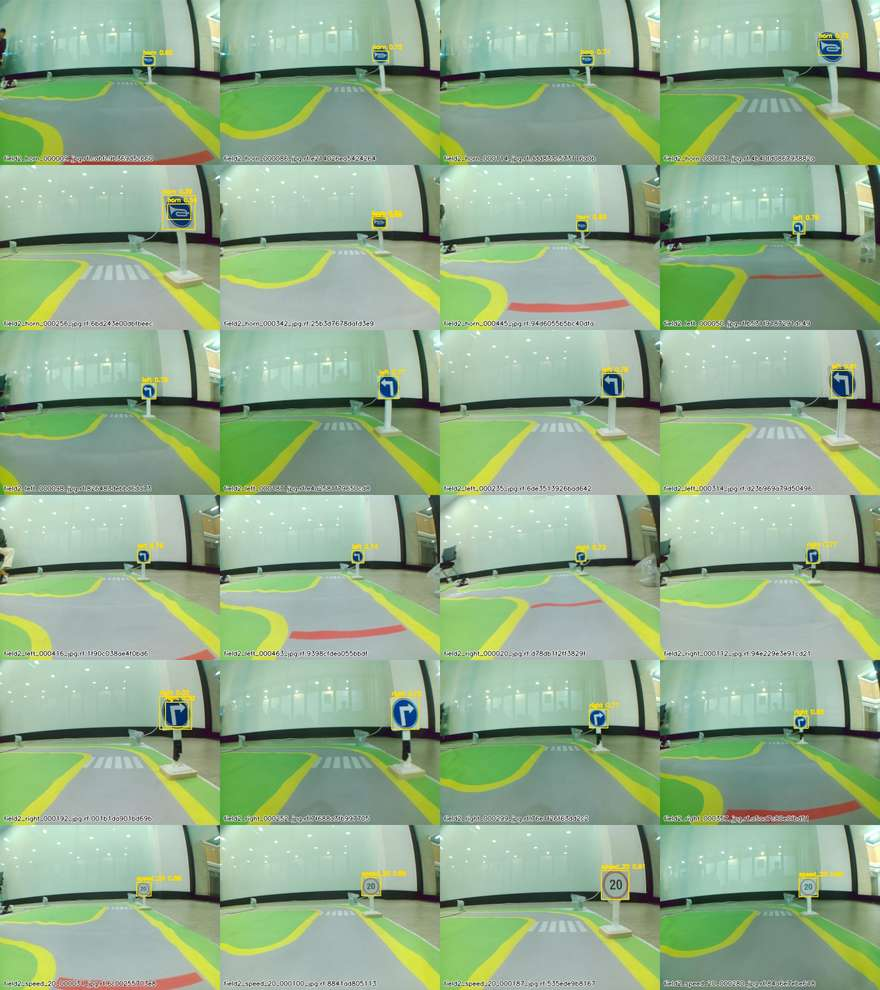

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\00_yolo_model_output_recheck\overlays\detections_test_light_aug.jpg


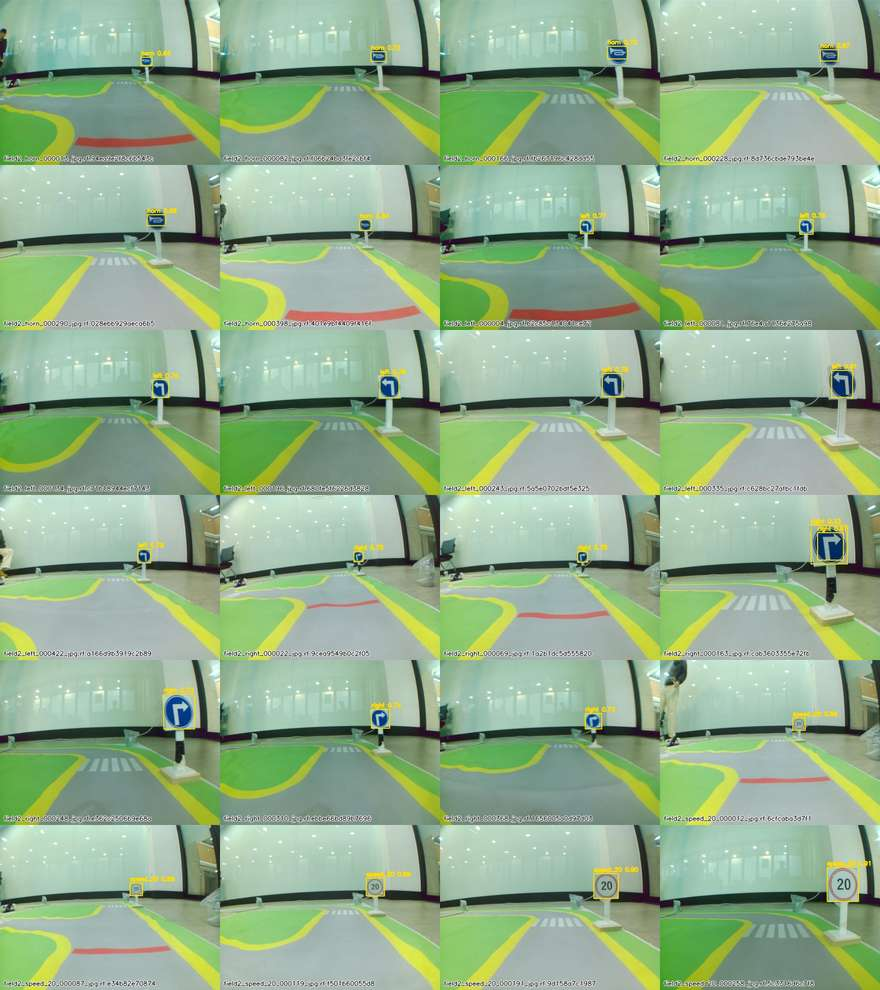

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\20_sign_event_contract\review_outputs\00_yolo_model_output_recheck\overlays\detections_runtime_event_captures.jpg


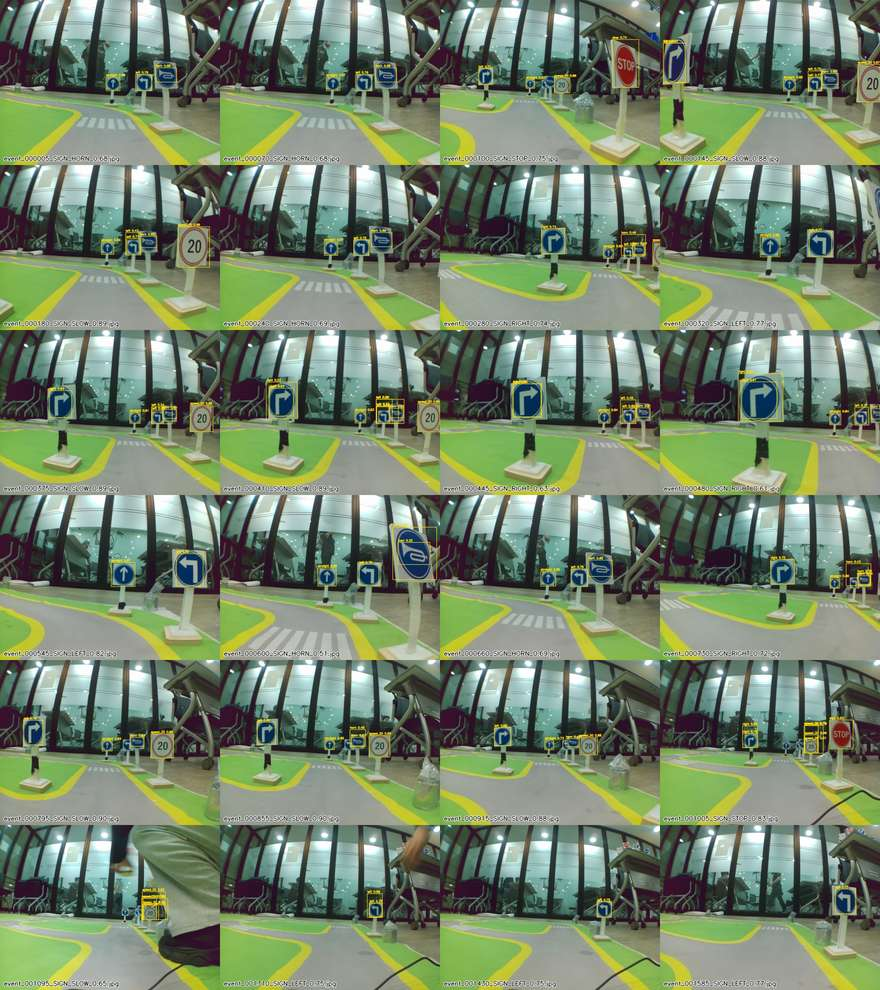

In [9]:
def draw_detections(image_path, rows, out_w=480):
    bgr = cv2.imread(str(image_path))
    if bgr is None:
        return None
    h, w = bgr.shape[:2]
    canvas = bgr.copy()
    for _, r in rows.iterrows():
        if int(r.get("det_index", -1)) < 0:
            continue
        x1, y1, x2, y2 = [int(round(float(r[k]))) for k in ["x1", "y1", "x2", "y2"]]
        label = f'{r["class_name"]} {float(r["conf"]):.2f}'
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 220, 255), 2)
        cv2.putText(canvas, label, (x1, max(18, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 220, 255), 2, cv2.LINE_AA)
    scale = out_w / float(w)
    out = cv2.resize(canvas, (out_w, int(round(h * scale))), interpolation=cv2.INTER_AREA)
    return out

def make_contact_sheet(det_df, out_path, max_images=24, cols=4):
    # detection이 있는 이미지 우선, 없으면 일부 no detection도 포함
    grouped = []
    for path, g in det_df.groupby("path", sort=False):
        has_det = (g["det_index"] >= 0).any()
        grouped.append((has_det, path, g))
    grouped = sorted(grouped, key=lambda x: (not x[0], x[1]))[:max_images]
    tiles = []
    for has_det, path, g in grouped:
        tile = draw_detections(path, g)
        if tile is None:
            continue
        title = Path(path).name[:42]
        cv2.putText(tile, title, (8, tile.shape[0] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(tile, title, (8, tile.shape[0] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1, cv2.LINE_AA)
        tiles.append(tile)
    if not tiles:
        return None
    max_h = max(t.shape[0] for t in tiles)
    max_w = max(t.shape[1] for t in tiles)
    padded = []
    for t in tiles:
        pad = np.full((max_h, max_w, 3), 245, dtype=np.uint8)
        pad[:t.shape[0], :t.shape[1]] = t
        padded.append(pad)
    rows = []
    for i in range(0, len(padded), cols):
        row_tiles = padded[i:i+cols]
        while len(row_tiles) < cols:
            row_tiles.append(np.full((max_h, max_w, 3), 245, dtype=np.uint8))
        rows.append(np.hstack(row_tiles))
    sheet = np.vstack(rows)
    cv2.imwrite(str(out_path), sheet)
    return out_path

sheet_paths = []
for set_name, g in det_df.groupby("set", sort=False):
    out_path = OVERLAY_DIR / f"detections_{set_name}.jpg"
    made = make_contact_sheet(g, out_path, max_images=24, cols=4)
    if made:
        sheet_paths.append(made)
        print(made)
        if IPyImage is not None:
            display(IPyImage(filename=str(made)))

## 9. 이번 노트북에서 얻어야 하는 해석

Run All 후 아래 질문에 답하면 된다.

1. 모델이 내보내는 class 이름과 bbox 형식을 이해했는가?
2. 한 프레임에서 sign bbox가 여러 개 뜨는 경우가 어느 정도 있는가?
3. confidence threshold를 너무 낮게 두면 어떤 class가 noisy하게 뜨는가?
4. bbox 크기와 위치가 event 발생 조건으로 쓸 수 있을 만큼 안정적인가?
5. 다음 노트북에서 ROI / bbox size / temporal voting / cooldown을 따로 실험할 준비가 되었는가?

다음 단계는 `01_sign_event_trigger_probe`가 될 가능성이 높다. 그때는 detection 자체가 아니라, **언제 state machine에 이벤트를 넘길지**를 다룬다.

In [10]:
summary = {
    "model_path": str(MODEL_PATH),
    "has_ultralytics": HAS_ULTRALYTICS,
    "has_onnxruntime": HAS_ONNXRUNTIME,
    "sample_image_count": int(len(samples_df)),
    "probe_image_count": int(len(probe_df)) if "probe_df" in globals() else 0,
    "observation_conf": float(CONF_FOR_OBSERVATION) if "CONF_FOR_OBSERVATION" in globals() else None,
    "imgsz": int(IMGSZ) if "IMGSZ" in globals() else None,
    "outputs": {
        "sample_manifest": str(TABLE_DIR / "sample_image_manifest.csv"),
        "raw_detection_observations": str(TABLE_DIR / "raw_detection_observations.csv"),
        "class_detection_distribution": str(TABLE_DIR / "class_detection_distribution.csv"),
        "overlay_dir": str(OVERLAY_DIR),
    },
    "note": "This notebook observes YOLO detection outputs only. Event trigger policy is intentionally not selected here.",
}
with open(OUT_DIR / "00_yolo_model_output_recheck_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "model_path": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\20_shared_assets\\models\\sign_yolo11n_field2_v1\\sign_yolo11n_field2_light_aug_best.onnx",
  "has_ultralytics": true,
  "has_onnxruntime": true,
  "sample_image_count": 144,
  "probe_image_count": 96,
  "observation_conf": 0.2,
  "imgsz": 640,
  "outputs": {
    "sample_manifest": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\20_sign_event_contract\\review_outputs\\00_yolo_model_output_recheck\\tables\\sample_image_manifest.csv",
    "raw_detection_observations": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\20_sign_event_contract\\review_outputs\\00_yolo_model_output_recheck\\tables\\raw_detection_observations.csv",
    "class_detection_distribution": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\20_sign_event_contract\\review_outputs\\00_yolo_model_output_recheck\\tables